In [1]:
from datetime import datetime, UTC
from urllib.parse import urlencode
from urllib.request import urlopen
from urllib.error import HTTPError, URLError
import json

BASE_URL = "https://api.kraken.com"


def to_datetime(timestamp: int) -> str:
    return datetime.fromtimestamp(timestamp, UTC).strftime(
        "%Y-%m-%d %H:%M:%S UTC"
    )


def get_ohlc(pair="BTC/USD", interval=1440, since=None):
    """
    Fetch OHLC candles from Kraken.

    Intervals:
        1      = 1 minute
        5      = 5 minutes
        15     = 15 minutes
        30     = 30 minutes
        60     = 1 hour
        240    = 4 hours
        1440   = 1 day
        10080  = 1 week
        21600  = 15 days
    """

    params = {
        "pair": pair,
        "interval": interval,
    }

    if since is not None:
        params["since"] = since

    url = f"{BASE_URL}/0/public/OHLC?{urlencode(params)}"

    try:
        with urlopen(url) as response:
            payload = json.load(response)

        if payload["error"]:
            raise RuntimeError(payload["error"])

        result = payload["result"]

        # Pair key is dynamic
        pair_key = next(k for k in result.keys() if k != "last")

        candles = []

        for candle in result[pair_key]:
            candles.append({
                "timestamp": candle[0],
                "datetime": to_datetime(candle[0]),
                "open": float(candle[1]),
                "high": float(candle[2]),
                "low": float(candle[3]),
                "close": float(candle[4]),
                "vwap": float(candle[5]),
                "volume": float(candle[6]),
                "trades": int(candle[7]),
            })

        return candles

    except HTTPError as e:
        raise RuntimeError(f"HTTP error: {e.code}") from e

    except URLError as e:
        raise RuntimeError(f"Connection error: {e.reason}") from e


if __name__ == "__main__":
    daily_btc = get_ohlc(
        pair="BTC/USD",
        interval=1440,   # daily candles
    )

    data = json.dumps(daily_btc, indent=2)

In [2]:
import pandas as pd

# create dataframe
df = pd.DataFrame(json.loads(data))

# convert datetime column to pandas datetime
df["datetime"] = pd.to_datetime(df["datetime"])

print(df.head())

    timestamp                  datetime     open     high      low    close  \
0  1719187200 2024-06-24 00:00:00+00:00  63176.1  63277.8  58448.0  60297.0   
1  1719273600 2024-06-25 00:00:00+00:00  60297.1  62364.8  60245.0  61794.0   
2  1719360000 2024-06-26 00:00:00+00:00  61794.1  62454.4  60689.9  60815.1   
3  1719446400 2024-06-27 00:00:00+00:00  60815.2  62297.8  60580.7  61617.1   
4  1719532800 2024-06-28 00:00:00+00:00  61617.1  62100.0  59942.7  60319.6   

      vwap       volume  trades  
0  60748.3  3701.591883   46612  
1  61359.5  1534.901479   25162  
2  61379.0   827.768786   19898  
3  61491.3   878.315496   20197  
4  60940.8   880.356744   21465  


In [3]:
df.drop(["timestamp", "vwap", "trades"], axis = 1, inplace = True)

df.head()

,datetime,open,high,low,close,volume
0,2024-06-24 00:00:00+00:00,63176.1,63277.8,58448.0,60297.0,3701.591883
1,2024-06-25 00:00:00+00:00,60297.1,62364.8,60245.0,61794.0,1534.901479
2,2024-06-26 00:00:00+00:00,61794.1,62454.4,60689.9,60815.1,827.768786
3,2024-06-27 00:00:00+00:00,60815.2,62297.8,60580.7,61617.1,878.315496
4,2024-06-28 00:00:00+00:00,61617.1,62100.0,59942.7,60319.6,880.356744


In [4]:
df_filtered = df[
    (df["datetime"] >= "2025-01-01") &
    (df["datetime"] <= "2026-04-30")
].reset_index(drop=True)

df_filtered

,datetime,open,high,low,close,volume
0,2025-01-01 00:00:00+00:00,93370.8,94888.0,92588.1,94380.8,576.162219
1,2025-01-02 00:00:00+00:00,94380.9,97719.9,94167.2,96805.2,1727.878345
2,2025-01-03 00:00:00+00:00,96805.3,98888.0,96034.1,98111.1,1520.228296
3,2025-01-04 00:00:00+00:00,98111.1,98714.8,97548.4,98208.9,630.752662
4,2025-01-05 00:00:00+00:00,98208.9,98750.0,97250.0,98306.2,437.304342
...,...,...,...,...,...,...
480,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952
481,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163
482,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391
483,2026-04-29 00:00:00+00:00,76331.9,77888.0,74940.0,75750.3,1865.527154


In [5]:
df = df_filtered.copy()

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime").reset_index(drop=True)

In [6]:
df["candle_body"] = df["close"] - df["open"]

In [7]:
df["ret1"] = df["close"].pct_change(1)
df["ret3"] = df["close"].pct_change(3)
df["ret7"] = df["close"].pct_change(7)

In [8]:
df["breakout_20"] = (
    df["close"] /
    df["high"].rolling(20).max()
)

df["breakdown_20"] = (
    df["close"] /
    df["low"].rolling(20).min()
)

In [9]:
from ta.momentum import RSIIndicator
from ta.trend import EMAIndicator

df["rsi"] = RSIIndicator(
    close=df["close"],
    window=14
).rsi()

In [10]:
df["ema20"] = EMAIndicator(
    close=df["close"],
    window=20
).ema_indicator()

In [11]:
df["ema20_dist"] = (
    (df["close"] - df["ema20"]) / df["ema20"]
)

In [12]:
df["future_return"] = (
    (df["close"].shift(-1) - df["close"]) / df["close"]
)

df["target"] = (
    df["candle_body"] > 0
).astype(int)

In [13]:
df["target"] = df["target"].shift(-1)
df = df.dropna().reset_index(drop=True)
df

,datetime,open,high,low,close,volume,candle_body,ret1,ret3,ret7,breakout_20,breakdown_20,rsi,ema20,ema20_dist,future_return,target
0,2025-01-20 00:00:00+00:00,101191.0,109112.0,99500.0,102162.8,6144.710114,971.8,0.009603,-0.018513,0.081235,0.936311,1.147822,62.042960,98494.274386,0.037246,0.039153,1.0
1,2025-01-21 00:00:00+00:00,102142.1,107200.0,100114.2,106162.8,2766.178680,4020.7,0.039153,0.017060,0.099448,0.972971,1.192763,68.920871,99224.610158,0.069924,-0.023683,0.0
2,2025-01-22 00:00:00+00:00,106162.8,106293.4,103271.3,103648.5,1391.420726,-2514.3,-0.023683,0.024285,0.031365,0.949928,1.164514,61.390642,99645.933001,0.040168,0.002621,1.0
3,2025-01-23 00:00:00+00:00,103648.6,106833.2,101281.7,103920.2,4692.190785,271.6,0.002621,0.017202,0.039444,0.952418,1.167567,61.875395,100053.006048,0.038651,0.008855,1.0
4,2025-01-24 00:00:00+00:00,103920.2,107080.6,102800.0,104840.4,1795.722536,920.2,0.008855,-0.012456,0.007211,0.960851,1.177905,63.544809,100508.948329,0.043095,-0.001290,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,2026-04-25 00:00:00+00:00,77455.0,77876.3,77145.3,77648.5,464.668651,193.5,0.002498,-0.007103,0.025350,0.976825,1.146359,62.752690,74746.713617,0.038822,0.012947,1.0
461,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,0.065371,0.989472,1.161201,65.148517,75118.817082,0.047059,-0.016262,0.0
462,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,0.020124,0.973381,1.098057,59.871659,75333.663074,0.027093,-0.013477,0.0
463,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,-0.000262,0.960262,1.083258,55.896652,75428.733258,0.011974,-0.007619,0.0


In [14]:
features_to_lag = [
    "open",
    "high",
    "low",
    "close",
    "candle_body",
    "volume",
    "rsi",
    "ema20_dist",
]

In [15]:
lags = 5

for feature in features_to_lag:
    
    for lag in range(1, lags + 1):
        
        df[f"{feature}_lag{lag}"] = (
            df[feature].shift(lag)
        )

In [16]:
df = df.dropna().reset_index(drop=True)

In [17]:
test_df = df[
    (df["datetime"] >= "2026-01-01") &
    (df["datetime"] <= "2026-04-30")
].reset_index(drop=True)

test_df

,datetime,open,high,low,close,volume,candle_body,ret1,ret3,ret7,...,rsi_lag1,rsi_lag2,rsi_lag3,rsi_lag4,rsi_lag5,ema20_dist_lag1,ema20_dist_lag2,ema20_dist_lag3,ema20_dist_lag4,ema20_dist_lag5
0,2026-01-01 00:00:00+00:00,87500.2,88779.3,87400.0,88731.8,1157.563409,1231.6,0.014077,0.018324,0.017590,...,44.596457,47.768020,42.427261,44.841024,44.634550,-0.008567,0.000749,-0.013514,-0.006796,-0.008079
1,2026-01-02 00:00:00+00:00,88730.0,90900.0,88273.3,89934.0,1901.882681,1204.0,0.013549,0.017331,0.030129,...,49.525758,44.596457,47.768020,42.427261,44.841024,0.004873,-0.008567,0.000749,-0.013514,-0.006796
2,2026-01-03 00:00:00+00:00,89934.0,90677.5,89300.0,90590.1,1113.010386,656.1,0.007295,0.035314,0.031747,...,53.842413,49.525758,44.596457,47.768020,42.427261,0.016698,0.004873,-0.008567,0.000749,-0.013514
3,2026-01-04 00:00:00+00:00,90590.1,91768.3,90590.0,91507.0,843.083779,916.9,0.010121,0.031276,0.041589,...,56.051436,53.842413,49.525758,44.596457,47.768020,0.021768,0.016698,0.004873,-0.008567,0.000749
4,2026-01-05 00:00:00+00:00,91507.0,94783.9,91489.5,93866.9,2070.652941,2359.9,0.025789,0.043731,0.077257,...,59.004227,56.051436,53.842413,49.525758,44.596457,0.028963,0.021768,0.016698,0.004873,-0.008567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,2026-04-25 00:00:00+00:00,77455.0,77876.3,77145.3,77648.5,464.668651,193.5,0.002498,-0.007103,0.025350,...,62.289351,65.530718,65.369968,61.489696,60.368487,0.040485,0.056116,0.061312,0.042907,0.040729
115,2026-04-26 00:00:00+00:00,77648.5,78964.8,77356.2,78653.8,726.374952,1005.3,0.012947,0.004729,0.065371,...,62.752690,62.289351,65.530718,65.369968,61.489696,0.038822,0.040485,0.056116,0.061312,0.042907
116,2026-04-27 00:00:00+00:00,78653.8,79481.2,76480.4,77374.7,2180.499163,-1279.1,-0.016262,-0.001037,0.020124,...,65.148517,62.752690,62.289351,65.530718,65.369968,0.047059,0.038822,0.040485,0.056116,0.061312
117,2026-04-28 00:00:00+00:00,77374.7,77799.0,75652.1,76331.9,1632.888391,-1042.8,-0.013477,-0.016956,-0.000262,...,59.871659,65.148517,62.752690,62.289351,65.530718,0.027093,0.047059,0.038822,0.040485,0.056116


In [18]:
test_df.columns

Index(['datetime', 'open', 'high', 'low', 'close', 'volume', 'candle_body',
       'ret1', 'ret3', 'ret7', 'breakout_20', 'breakdown_20', 'rsi', 'ema20',
       'ema20_dist', 'future_return', 'target', 'open_lag1', 'open_lag2',
       'open_lag3', 'open_lag4', 'open_lag5', 'high_lag1', 'high_lag2',
       'high_lag3', 'high_lag4', 'high_lag5', 'low_lag1', 'low_lag2',
       'low_lag3', 'low_lag4', 'low_lag5', 'close_lag1', 'close_lag2',
       'close_lag3', 'close_lag4', 'close_lag5', 'candle_body_lag1',
       'candle_body_lag2', 'candle_body_lag3', 'candle_body_lag4',
       'candle_body_lag5', 'volume_lag1', 'volume_lag2', 'volume_lag3',
       'volume_lag4', 'volume_lag5', 'rsi_lag1', 'rsi_lag2', 'rsi_lag3',
       'rsi_lag4', 'rsi_lag5', 'ema20_dist_lag1', 'ema20_dist_lag2',
       'ema20_dist_lag3', 'ema20_dist_lag4', 'ema20_dist_lag5'],
      dtype='str')

In [19]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(
    model="phi4-mini",
    temperature=0
)

SYSTEM_PROMPT = """
You are a Financial Technical Analyst.
Your role is, given a set of technical and price action indicators, to analize the overall context and return wheter the outlook for the next trading day is gonna be bullish, bearish, or neutral.
"""

rsi = test_df.loc[0, "rsi"]

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human", "here's the current rsi reading: {rsi}")
])

chain = prompt | llm

response = chain.invoke({
    "rsi": rsi
})

print(response.content)

The RSI (Relative Strength Index) measures overboughtness/oversoldness of an asset by comparing its current price to a previous closing price usually on shorter time frames like daily.

An RSI value above 70 typically indicates that there is more selling pressure than buying, suggesting the market may be considered oversold. Conversely, values below 30 indicate strong bullish momentum and potentially overbought conditions in which buyers are dominating sellers.


Given an extremely high reading of RSIs at **49.525757876801514**, this value appears to have been mistakenly inputted as it is significantly higher than typical RSI readings (which usually range from -100 to +100). Assuming there was a typo and the actual RSI should be around 50, which falls within neutral territory.

However, if we consider an extremely high reading like **49.525757876801514**:

- This would indicate extreme overbought conditions.
- The market is likely experiencing significant selling pressure or panic amon

In [20]:
from typing import Literal
from pydantic import BaseModel, Field

class MarketOutlook(BaseModel):
    outlook: Literal["bullish", "bearish", "neutral"] = Field(
        description="Expected market direction for the next trading day"
    )
    reasoning: str = Field(
        description="Complete Explanation of the analysis and reasoning behind it."
    )

In [21]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(
    #model="phi4-mini-reasoning:3.8b",
    model = "llama3.1:8b",
    temperature=0
)

structured_llm = llm.with_structured_output(MarketOutlook)

SYSTEM_PROMPT = """
You are a Financial Technical Analyst.
You are Analyzing Bitcoin Daily Prices.
Your role is, given a set of technical and price action indicators,
to analyze the overall context, perform an analsys, and return whether the outlook for
the next trading day is bullish, bearish, or neutral with a complete analisys.
"""

TA_PROMPT = """
You are given the following Technical and Price Action Indicators.
First, here are the Previous 5 Day Open High Low Close, with respective current readings.
Previous 5 Day Open Prices: {open_lag5}, {open_lag4}, {open_lag3}, {open_lag2}, {open_lag1}
Here's the Current Open Price: {open}
Previous 5 Day High Prices: {high_lag5}, {high_lag4}, {high_lag3}, {high_lag2}, {high_lag1}
Here's the Current High Price: {high}
Previous 5 Day Low Prices: {low_lag5}, {low_lag4}, {low_lag3}, {low_lag2}, {low_lag1}
Here's the Current Low Price: {low}
Previous 5 Day Close Prices: {close_lag5}, {close_lag4}, {close_lag3}, {close_lag2}, {close_lag1}
Here's the Current Close Price: {close}

Then, you are given the 3 day and 7 day returns:
3 Day Returns: {ret3}
7 Day Returns: {ret7}

Then I want you to analyze the volumes, as they act as confirmation, where higher volumes confirm directional hyphothesis and lower volumes discard them.
Previous 5 Day Volumes: {volume_lag5}, {volume_lag4}, {volume_lag3}, {volume_lag2}, {volume_lag1}
Here's the Current Volumes: {volume}

Then I want you to analize the previous 5 day trend of RSI readings and then the current RSI reading.
Previous 5 Day RSI: {rsi_lag5}, {rsi_lag4}, {rsi_lag3}, {rsi_lag2}, {rsi_lag1}
Here's the current RSI reading: {rsi}

Now it's time for the distance of the close price to the EMA(20)
Previous 5 Day EMA Distances: {ema20_dist_lag5}, {ema20_dist_lag4}, {ema20_dist_lag3}, {ema20_dist_lag2}, {ema20_dist_lag1}
Here's the current EMA Distance from the Close Price {ema20_dist}

INSTRUCTIONS:
For Open High Low Close Prices, analyze carefully whether the price is compressing or expanding, where when compressing means that volatility is low and confidence in the trade is low, viceversa,
when the price is expanding means that volatility is increasing and confirms trading hyphothesis.

For the RSI, analyze carefully the overall trend and the current reading.
A sideways trend for the RSI indicates a neutral signal.
An uptrend for the RSI indicates a bullish signal if the values are below the 70 mark, if values are uptrending above the 70 mark it's a bearish signal.
A downtrend for the RSI indicates a bearish signal if the values are above the 30 mark, if values are downtrending below the 30 mark it's a bullish signal.

For the Distance from the EMA, closer values to 0 indicate a neutral signal.
Values above the 0 indicate a bullish signal, but only if they are uptrending, while if they are downtrending above the 0 it's a bearish signal.
Values below the 0 indicate a bearish signal, but only if they are downtrending, while if they are uptrending below the 0 it's a bullish signal.

For the Volumes, use them as confirmation for your trading decision, where higher volumes confirm trading hypothesis.

You can use the 3 Day Returns as short term momentum indicator, and the 7 Day Returns as medium term momentum indicator.
When the 7 Day Returns are negative but the 3 Day Returns are positive, that might mean a bullish reversal, hence, it's a Bullish Signal.
When the 7 Day Returns are positive but the 3 Day Returns are negative, that might mean a bearish reversal, hence, it's a Bearish Signal.
If the 7 Day and 3 Day returns are both positive, it's a bullish signal, while if they are both negative, it's a bearish signal.

When Indicators and Price Action are giving mixed signals, that's a Neutral Trading Signal.
If the majority of Indicators and Price Action are giving Bullish Sentiment, then it's a Bullish Signal.
If the majority of Indicators and Price Action are giving Bearish Sentiment, then it's a Bearish Signal.

DELIVERY:

Deliver a market outlook for the next trading day, which can be Bullish, Bearish, or Neutral.
Also Deliver a Complete Analysis which will contain the reasoning behind the Trading Signal.
Only use "'" when formatting the output and not elsewhere.
"""

rsi = test_df.loc[0, "rsi"]
rsi_lag5 = test_df.loc[0, "rsi_lag5"]
rsi_lag4 = test_df.loc[0, "rsi_lag4"]
rsi_lag3 = test_df.loc[0, "rsi_lag3"]
rsi_lag2 = test_df.loc[0, "rsi_lag2"]
rsi_lag1 = test_df.loc[0, "rsi_lag1"]

ema20_dist = test_df.loc[0, "ema20_dist"]
ema20_dist_lag5 = test_df.loc[0, "ema20_dist_lag5"]
ema20_dist_lag4 = test_df.loc[0, "ema20_dist_lag4"]
ema20_dist_lag3 = test_df.loc[0, "ema20_dist_lag3"]
ema20_dist_lag2 = test_df.loc[0, "ema20_dist_lag2"]
ema20_dist_lag1 = test_df.loc[0, "ema20_dist_lag1"]

open_ = test_df.loc[0, "open"]
open_lag5 = test_df.loc[0, "open_lag5"]
open_lag4 = test_df.loc[0, "open_lag4"]
open_lag3 = test_df.loc[0, "open_lag3"]
open_lag2 = test_df.loc[0, "open_lag2"]
open_lag1 = test_df.loc[0, "open_lag1"]

high = test_df.loc[0, "high"]
high_lag5 = test_df.loc[0, "high_lag5"]
high_lag4 = test_df.loc[0, "high_lag4"]
high_lag3 = test_df.loc[0, "high_lag3"]
high_lag2 = test_df.loc[0, "high_lag2"]
high_lag1 = test_df.loc[0, "high_lag1"]

low = test_df.loc[0, "low"]
low_lag5 = test_df.loc[0, "low_lag5"]
low_lag4 = test_df.loc[0, "low_lag4"]
low_lag3 = test_df.loc[0, "low_lag3"]
low_lag2 = test_df.loc[0, "low_lag2"]
low_lag1 = test_df.loc[0, "low_lag1"]

close = test_df.loc[0, "close"]
close_lag5 = test_df.loc[0, "close_lag5"]
close_lag4 = test_df.loc[0, "close_lag4"]
close_lag3 = test_df.loc[0, "close_lag3"]
close_lag2 = test_df.loc[0, "close_lag2"]
close_lag1 = test_df.loc[0, "close_lag1"]

volume = test_df.loc[0, "volume"]
volume_lag5 = test_df.loc[0, "volume_lag5"]
volume_lag4 = test_df.loc[0, "volume_lag4"]
volume_lag3 = test_df.loc[0, "volume_lag3"]
volume_lag2 = test_df.loc[0, "volume_lag2"]
volume_lag1 = test_df.loc[0, "volume_lag1"]

ret3 = test_df.loc[0, "ret3"]
ret7 = test_df.loc[0, "ret7"]

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human", TA_PROMPT)
])

chain = prompt | structured_llm

response = chain.invoke({
    "rsi": rsi,
    "rsi_lag5": rsi_lag5,
    "rsi_lag4": rsi_lag4,
    "rsi_lag3": rsi_lag3,
    "rsi_lag2": rsi_lag2,
    "rsi_lag1": rsi_lag1,
    "ema20_dist": ema20_dist,
    "ema20_dist_lag5": ema20_dist_lag5,
    "ema20_dist_lag4": ema20_dist_lag4,
    "ema20_dist_lag3": ema20_dist_lag3,
    "ema20_dist_lag2": ema20_dist_lag2,
    "ema20_dist_lag1": ema20_dist_lag1,
    "open": open_,
    "open_lag5": open_lag5,
    "open_lag4": open_lag4,
    "open_lag3": open_lag3,
    "open_lag2": open_lag2,
    "open_lag1": open_lag1,
    "high": high,
    "high_lag5": high_lag5,
    "high_lag4": high_lag4,
    "high_lag3": high_lag3,
    "high_lag2": high_lag2,
    "high_lag1": high_lag1,
    "low": low,
    "low_lag5": low_lag5,
    "low_lag4": low_lag4,
    "low_lag3": low_lag3,
    "low_lag2": low_lag2,
    "low_lag1": low_lag1,
    "close": close,
    "close_lag5": close_lag5,
    "close_lag4": close_lag4,
    "close_lag3": close_lag3,
    "close_lag2": close_lag2,
    "close_lag1": close_lag1,
    "volume": volume,
    "volume_lag5": volume_lag5,
    "volume_lag4": volume_lag4,
    "volume_lag3": volume_lag3,
    "volume_lag2": volume_lag2,
    "volume_lag1": volume_lag1,
    "ret3": ret3,
    "ret7": ret7
})

print(response)
print(response.outlook)
print(response.reasoning)

outlook='bullish' reasoning="The price action is expanding, indicating increasing volatility and confidence in the trade. The RSI is uptrending with a current reading of 49.53, which is below the 70 mark, indicating a bullish signal. The distance from the EMA is positive at 0.004873227116554597, indicating a bullish signal. The volumes are higher than the previous day's volume, confirming the bullish hypothesis. The 7-day returns are positive at 0.01758985297827942 and the 3-day returns are also positive at 0.01832441805885332, indicating a bullish momentum. Overall, the majority of indicators and price action are giving bullish sentiment."
bullish
The price action is expanding, indicating increasing volatility and confidence in the trade. The RSI is uptrending with a current reading of 49.53, which is below the 70 mark, indicating a bullish signal. The distance from the EMA is positive at 0.004873227116554597, indicating a bullish signal. The volumes are higher than the previous day's

In [24]:
predictions = []
analysis = []

for idx, row in test_df.iterrows():
    print(idx)
    response = chain.invoke({
        "rsi": row["rsi"],
        "rsi_lag5": row["rsi_lag5"],
        "rsi_lag4": row["rsi_lag4"],
        "rsi_lag3": row["rsi_lag3"],
        "rsi_lag2": row["rsi_lag2"],
        "rsi_lag1": row["rsi_lag1"],

        "ema20_dist": row["ema20_dist"],
        "ema20_dist_lag5": row["ema20_dist_lag5"],
        "ema20_dist_lag4": row["ema20_dist_lag4"],
        "ema20_dist_lag3": row["ema20_dist_lag3"],
        "ema20_dist_lag2": row["ema20_dist_lag2"],
        "ema20_dist_lag1": row["ema20_dist_lag1"],

        "open": row["open"],
        "open_lag5": row["open_lag5"],
        "open_lag4": row["open_lag4"],
        "open_lag3": row["open_lag3"],
        "open_lag2": row["open_lag2"],
        "open_lag1": row["open_lag1"],

        "high": row["high"],
        "high_lag5": row["high_lag5"],
        "high_lag4": row["high_lag4"],
        "high_lag3": row["high_lag3"],
        "high_lag2": row["high_lag2"],
        "high_lag1": row["high_lag1"],

        "low": row["low"],
        "low_lag5": row["low_lag5"],
        "low_lag4": row["low_lag4"],
        "low_lag3": row["low_lag3"],
        "low_lag2": row["low_lag2"],
        "low_lag1": row["low_lag1"],

        "close": row["close"],
        "close_lag5": row["close_lag5"],
        "close_lag4": row["close_lag4"],
        "close_lag3": row["close_lag3"],
        "close_lag2": row["close_lag2"],
        "close_lag1": row["close_lag1"],

        "volume": row["volume"],
        "volume_lag5": row["volume_lag5"],
        "volume_lag4": row["volume_lag4"],
        "volume_lag3": row["volume_lag3"],
        "volume_lag2": row["volume_lag2"],
        "volume_lag1": row["volume_lag1"],

        "ret3": row["ret3"],
        "ret7": row["ret7"]
    })
    analysis.append(response.reasoning)
    predictions.append(response.outlook)

test_df["prediction"] = predictions

position_map = {
    "bullish": 1,
    "bearish": -1,
    "neutral": 0
}

test_df["position"] = test_df["prediction"].map(position_map)

test_df["strategy_return"] = (
    test_df["position"] *
    test_df["future_return"]
)

test_df["strategy_equity"] = (
    1 + test_df["strategy_return"]
).cumprod()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118


In [26]:
test_df.to_csv("AgenticTrader_Results.csv")

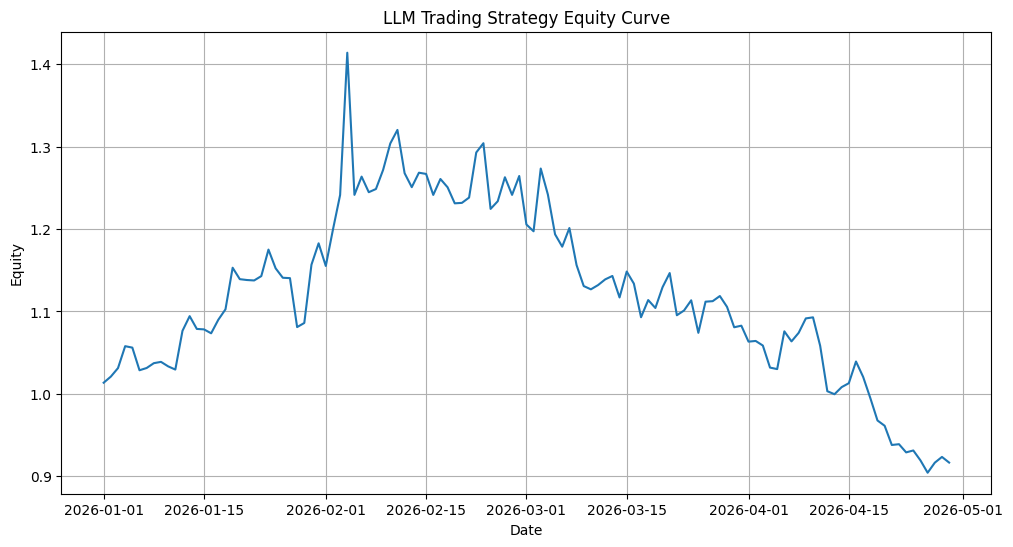

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    test_df["datetime"],
    test_df["strategy_equity"]
)

plt.title("LLM Trading Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)

plt.show()